<img src="https://siwi.org/wp-content/uploads/2021/09/colorful-water-drop-splash-e1635164525186.jpg"/>

<h1 id="1" style="color:#ffee71; background:#2997bf;">
    <center>
        Section 1 - SciKit Learn
    </center>
</h1>

SciKit Learn has been developed for predictive tasks

**Import Libraries/Dependencies**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from seaborn import heatmap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

**Import Data**

In [108]:
# df = pd.read_excel('2023_09_26_Data_No_Noise.xlsx')
df = pd.read_excel('2023_09_26_Data_With_Noise.xlsx')

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Obs. No.   100 non-null    int64  
 1   Property1  100 non-null    int64  
 2   Property2  100 non-null    float64
 3   Property3  100 non-null    float64
 4   Property4  100 non-null    int64  
 5   Property5  100 non-null    int64  
 6   Price      100 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 5.6 KB


In [110]:
# We delete the column with the obs. no. 
df = df.drop(['Obs. No.'], axis = 1)

In [111]:
df.head()

,Property1,Property2,Property3,Property4,Property5,Price
0,9,1528.04,53.438869,839,0,83028.226356
1,2,1205.15,52.304596,714,1,92443.658640
2,7,1628.35,44.539375,871,0,88218.059625
3,5,1264.71,56.655505,655,1,56910.012352
4,2,1205.84,66.100193,1007,1,76436.427524


**Descriptive Analysis**

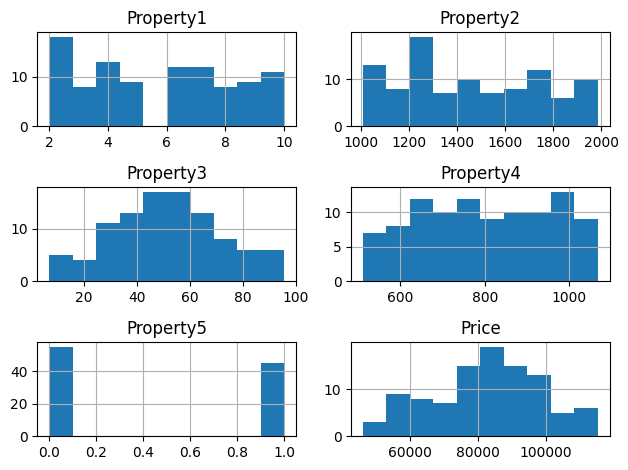

In [112]:
# Histograms
df.hist()
plt.tight_layout()
plt.show()

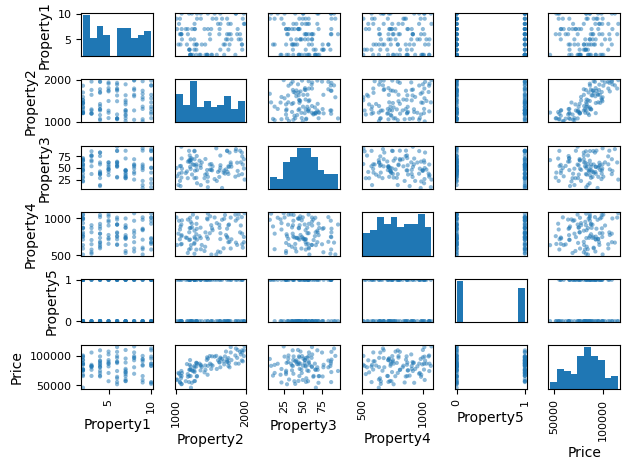

In [113]:
# Scatter plot
pd.plotting.scatter_matrix(df)
plt.tight_layout()
plt.show()

In [114]:
df.corr()['Price'].sort_values(ascending = False)[1:]

Property2    0.799150
Property4    0.118262
Property3    0.059802
Property1    0.029257
Property5    0.019661
Name: Price, dtype: float64

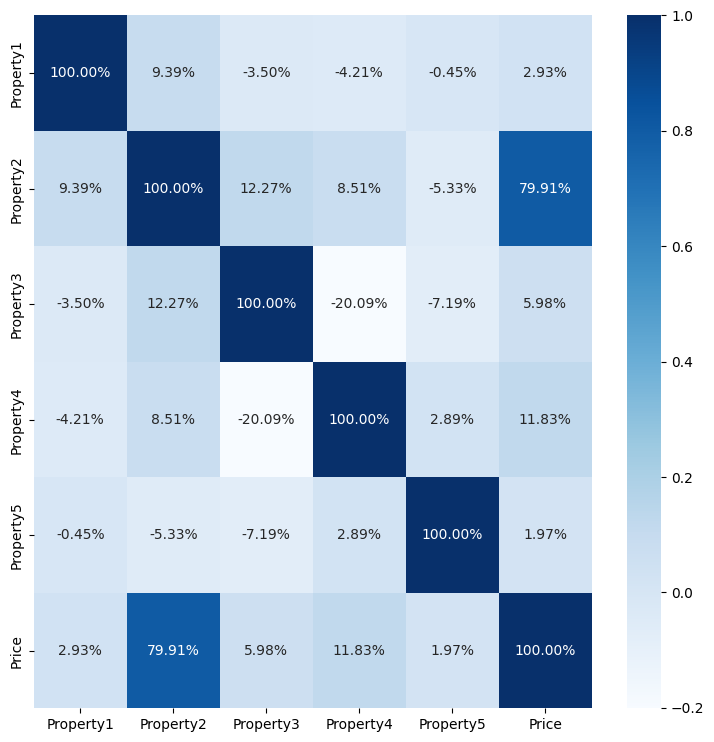

In [115]:
plt.figure(figsize = (9, 9))
heatmap(df.corr(), cmap = 'Blues', annot = True, fmt = '.2%')
plt.show()

In [116]:
# We split the data into y and X
y = df['Price']
X = df.drop(['Price'], axis = 1)

In [117]:
# We split the data training set and test set
train_y, test_y, train_X, test_X = train_test_split(y, X, train_size = 0.8, random_state = 42)

**Linear Regression**

In [118]:
# Define the linear regression model
model = LinearRegression()

In [119]:
# We fit our model to the data
model = model.fit(train_X, train_y)

In [120]:
# Coefficients
model.coef_

array([166.38956679,  42.36911369,  33.81803497,   2.02878104,
        18.67722217])

### Linear Regression

In [121]:
y_train_pred = model.predict(train_X)
y_test_pred = model.predict(test_X)

print('Score of Training set', r2_score(train_y, y_train_pred))
print('Score of Test set', r2_score(test_y, y_test_pred))


Score of Training set 0.64794423095199
Score of Test set 0.5372787484982986


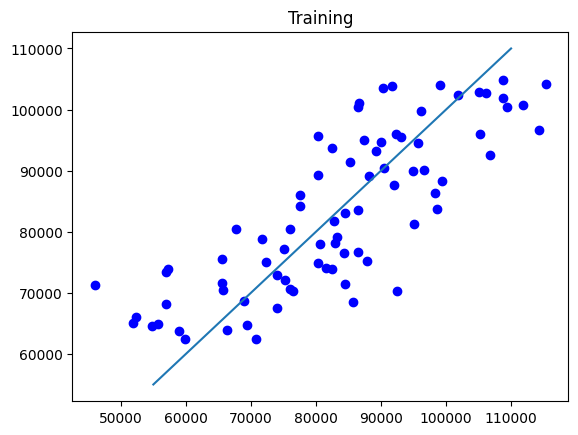

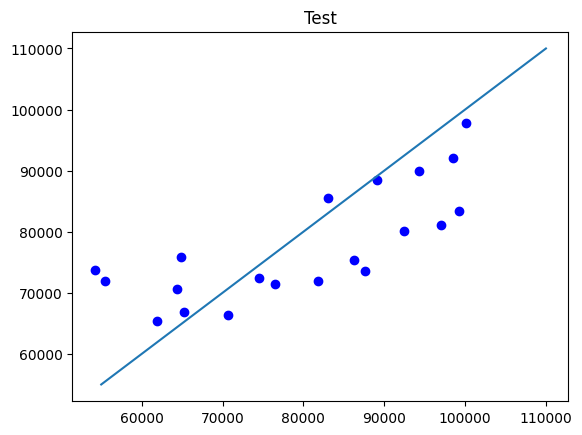

In [122]:
# Scatter plots

line = np.linspace(55000, 110000, 100)

plt.figure(1)
plt.scatter(train_y, y_train_pred, color = 'blue')
plt.plot(line, line)
plt.title('Training')
plt.show()

plt.figure(2)
plt.scatter(test_y, y_test_pred, color = 'blue')
plt.plot(line, line)
plt.title('Test')
plt.show()

<h1 id="2" style="color:#ffee71; background:#2997bf;">
    <center>
        Section 2 - StatsModels
    </center>
</h1>

Statsmodels has been developed for explanetory tasks.

In [18]:
import statsmodels.api as sm

In [19]:
# df = pd.read_excel('2023_09_26_Data_No_Noise.xlsx')
df = pd.read_excel('2023_09_26_Data_With_Noise.xlsx')

In [20]:
# We delete the column with the obs. no. 
df = df.drop(['Obs. No.'], axis = 1)

In [21]:
# We split the data into y and X
y = df.Price
X = df.drop(['Price'], axis = 1)

In [22]:
# Create model
model = sm.OLS(y, X)

In [23]:
# Fit the model
model = model.fit()

In [24]:
# Summary
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Price   R-squared (uncentered):                   0.987
Model:                            OLS   Adj. R-squared (uncentered):              0.986
Method:                 Least Squares   F-statistic:                              1429.
Date:                Wed, 08 Nov 2023   Prob (F-statistic):                    9.95e-88
Time:                        22:25:53   Log-Likelihood:                         -1059.1
No. Observations:                 100   AIC:                                      2128.
Df Residuals:                      95   BIC:                                      2141.
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Property1    -69.7498    359.987     -0.194      0.847    -784.414     644.914
Property2     47.8495      3.024     15.822      0.000      41.846      53.853
Property3     18.2972     45.305      0.404      0.687     -71.644     108.238
Property4     13.1702      4.856      2.712      0.008       3.529      22.811
Property5   2503.4168   1969.795      1.271      0.207   -1407.120    6413.954
==============================================================================
Omnibus:                        3.115   Durbin-Watson:                   1.859
Prob(Omnibus):                  0.211   Jarque-Bera (JB):                2.111
Skew:                          -0.158   Prob(JB):                        0.348
Kurtosis:                       2.362   Cond. No.                     3.37e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 3.37e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""